# 1.0. Page de garde

Titre : **IA de détection précoce du décrochage étudiant**

Certification : **Concevoir et implémenter une solution d’intelligence artificielle**

Nom/prénom : **Valeux/marc**

Date : **24/08/2026**

Version : **1.0**

Environnement d’exécution : **python 3.13**

Code source : https://github.com/marc-proxiel/ProjetDecrochage

# 2.1. Résumé exécutif (problème, objectif, approche, résultats clés, limites)

### **Résumé Exécutif : Détection précoce du décrochage étudiant**

*   **Problème**
    L’université fait face à un **taux d’abandon élevé en première année de licence (L1)**, estimé à environ **28 %** dans le jeu de données actuel. Certaines filières, comme la Biologie ou l'Informatique, affichent des taux de réussite historiques ne dépassant pas 60 %. L'enjeu est d'intervenir avant que le décrochage ne soit définitif, car les difficultés non détectées représentent un coût important pour l'institution et l'étudiant.

*   **Objectif**
    L'objectif principal est de concevoir une solution d'IA capable de **prédire le risque de décrochage** (classification binaire) dès le milieu du premier semestre. En complément, le modèle doit **estimer la moyenne finale** (régression) pour permettre à la Direction de la réussite étudiante de prioriser et de calibrer les dispositifs d’accompagnement, tels que le tutorat ou l'aide sociale.

*   **Approche**
    Le projet suit une démarche de bout en bout (compétences C1 à C9) intégrée dans un **notebook Jupyter unique**. L'approche repose sur :
    *   Le **traitement de données brutes** complexes (doublons, valeurs manquantes, formats hétérogènes) et l'exclusion de **variables "leurres"** sans pouvoir prédictif.
    *   Une rigueur méthodologique stricte pour éviter les **fuites de données** (*data leakage*), en excluant notamment la moyenne finale et les résultats consolidés de fin de semestre lors de la phase de prédiction à mi-parcours.
    *   La comparaison de plusieurs familles de modèles (ex: régression logistique, arbres, boosting) pour sélectionner la meilleure performance.

*   **Résultats clés attendus**
    *   **Performance technique :** Un modèle validé par sa **courbe ROC et son AUC**, ainsi qu'une analyse de la matrice de confusion.
    *   **Indicateurs métiers :** Une justification du seuil de classification basée sur le **coût d'un faux négatif** (étudiant à risque non détecté).
    *   **Explicabilité :** Fournir aux équipes pédagogiques une lecture claire des facteurs de risque (ex: importance des variables).
    *   **Industrialisation :** Une architecture cible incluant un plan de monitoring (MLOps) pour détecter la dérive des données dans le temps.

*   **Limites et Risques**
    *   **Éthique et Biais :** L'utilisation de **variables sensibles** (sexe, statut de boursier) présente un risque de biais discriminatoires qu'il convient d'analyser.
    *   **Dilemme du marquage :** Le risque de stigmatisation des étudiants identifiés comme "à risque" doit être géré par des garde-fous éthiques.
    *   **Qualité des données :** La présence de près de 12 % de données manquantes sur certaines variables clés et le caractère partiel des données à mi-S1 peuvent limiter la précision du modèle.
# Contexte
Une université pluridisciplinaire constate un taux d’abandon élevé en première année de licence (L1). La direction de la réussite étudiante souhaite déployer une solution d’intelligence artificielle de détection précoce du décrochage afin d’identifier, **dès le milieu du premier semestre**, les étudiants à risque et de déclencher des dispositifs d’accompagnement (tutorat, soutien méthodologique, aide sociale).
Les objectifs métier de la solution sont les suivants :

- prédire, à mi-parcours, le risque de décrochage (interruption de la formation) d’un étudiant à partir de ses données académiques, d’engagement et de contexte ;
- estimer la moyenne finale attendue afin de prioriser et calibrer l’accompagnement ;
- fournir aux équipes pédagogiques des indicateurs explicables, tout en garantissant un usage éthique et conforme des données étudiantes. 

# 3.2. Cadrage métier et cas d’usage
Le **cadrage métier** et le **cas d'usage** de ce projet concernent la mise en place d'une solution d'intelligence artificielle pour la **détection précoce du décrochage étudiant** au sein d'une université pluridisciplinaire.

Voici les composantes détaillées de ce cadrage :

### **1. Problématique Métier**
L'université fait face à un **taux d’abandon élevé en première année de licence (L1)**. Les données indiquent un taux d'abandon moyen d'environ **28 %**. L'enjeu est de pouvoir intervenir de manière proactive dès le **milieu du premier semestre (mi-S1)**, moment où les dispositifs d'accompagnement peuvent encore être efficaces pour redresser la trajectoire de l'étudiant.

### **2. Objectifs de la Solution**
La direction de la réussite étudiante a défini trois objectifs majeurs pour cet outil :
*   **Prédire le risque de décrochage :** Identifier, à mi-parcours, les étudiants susceptibles d'interrompre leur formation (classification binaire).
*   **Estimer la performance académique :** Prédire la moyenne finale attendue afin de **prioriser et calibrer l’accompagnement** nécessaire (régression).
*   **Aider à la décision pédagogique :** Fournir des indicateurs explicables aux enseignants pour qu'ils comprennent les facteurs de risque, tout en respectant l'éthique et le RGPD.

### **3. Nature Technique du Cas d'Usage**
Il s'agit d'un problème d'**apprentissage supervisé mixte** :
*   **Cible principale (Classification) :** Variable `abandon` (0 ou 1).
*   **Cible secondaire (Régression) :** Variable `moyenne_finale` (note sur 20).
*   **Périmètre temporel :** Le scoring doit être réalisé exclusivement avec des données disponibles à la mi-S1 pour éviter toute **fuite temporelle** (ne pas utiliser les résultats consolidés de fin de semestre comme `moyenne_partiels_s1`).

### **4. Actions Déclenchées**
La détection d'un risque élevé doit permettre de déclencher des leviers spécifiques :
*   **Tutorat** par des pairs.
*   **Soutien méthodologique** pour l'organisation du travail.
*   **Aide sociale** pour les étudiants en difficulté financière (le statut de boursier ou les heures de travail rémunéré étant des facteurs d'influence).

 
## Les enjeux financiers et optimisation des ressources
L'échec et le décrochage représentent un coût significatif pour l'institution :

Coût de l'échec non détecté : Dans l'évaluation de la solution, l'université identifie explicitement le « coût d'un faux négatif ». Un étudiant en situation de décrochage qui n'est pas soutenu à temps représente un investissement pédagogique et administratif perdu pour l'année en cours.
Optimisation des dispositifs d'aide : La direction de la réussite étudiante doit « calibrer l’accompagnement ». Identifier précisément les besoins permet de mieux répartir les budgets alloués au tutorat, au soutien méthodologique et à l'aide sociale, évitant ainsi le gaspillage de ressources sur des profils ne présentant pas de risques réels.
Gestion des capacités d'accueil : Le catalogue des formations montre des capacités d'accueil limitées (ex: 980 places en Informatique, 830 en Droit). Un taux d'abandon élevé (actuellement autour de 28 %) signifie qu'une part importante de ces places financées ne débouche sur aucun diplôme, réduisant l'efficience du service public

## Enjeux sociaux et lutte contre la précarité
- Étudiants salariés et boursiers : Une partie des étudiants travaille jusqu'à 30 heures par semaine en parallèle de leurs études. L'échec académique pour ces profils, souvent boursiers, peut aggraver leur précarité financière et compromettre leur avenir professionnel.
- Mobilité sociale : En intervenant dès le milieu du premier semestre, l'université cherche à éviter que des facteurs socio-économiques (comme la distance domicile-campus ou la charge de travail rémunéré) ne deviennent des barrières insurmontables à la réussite

## Enjeux institutionnels et d'image
- Missions de la « Direction de la réussite étudiante » : Cette entité a pour mission directe de redresser les taux de réussite historiques qui sont parfois faibles (60 % en Biologie ou Informatique). Améliorer ces indicateurs est crucial pour l'attractivité de l'université.
- Éthique et bien-être : L'université se préoccupe de l'impact psychologique du décrochage. Elle doit éviter qu'une détection de risque ne stigmatise l'étudiant, tout en renforçant son sentiment d'appartenance et sa satisfaction vis-à-vis de la formation

**Un faux positif** correspond à un étudiant qui est prédit à tort comme étant en risque de décrochage. Le coût pour l'institution se décline selon trois axes principaux :

- Le gaspillage de ressources : L'université mobilise inutilement des « dispositifs d’accompagnement » tels que le tutorat, le soutien méthodologique ou l'aide sociale pour des étudiants qui n'en ont pas réellement besoin. Cela représente une perte d'efficience budgétaire et humaine, car ces ressources sont limitées et pourraient être mieux allouées à des profils réellement fragiles.
- Le « dilemme du marquage » : C'est un enjeu éthique. Identifier à tort un étudiant comme étant « à risque » peut avoir des conséquences psychologiques négatives, créer un sentiment de stigmatisation ou modifier la perception que l'étudiant a de ses propres capacités, ce qui pourrait paradoxalement nuire à son parcours.
- La saturation des capacités d'accueil : les filières ont des capacités d'accueil limitées pour ne pas encombrer les dispositifs de soutien au détriment de ceux qui en dépendent pour réussir.

##   Résumé des enjeux
Eviter l'échec est un levier pour rentabiliser l'investissement public, assurer la mission de promotion sociale de l'université et garantir la pérennité de ses filières les plus sous tension.
**Éviter ces faux négatifs** est au cœur de la mission de la « Direction de la réussite étudiante », car chaque abandon représente une perte par rapport aux capacités d'accueil limitées des filières et aux taux de réussite historiques à redresser.


## Faux positif ou Faux négatif ?
D'après les sources, il n'y a pas de réponse unique, car le choix dépend de l'arbitrage politique et budgétaire de l'université. Cependant, l'énoncé de la certification met un accent particulier sur la gestion des **faux négatifs**, tout en soulignant les risques éthiques des **faux positifs**.


### **1. La priorité au faux négatif (Le risque de l'échec non détecté)**
Un faux négatif est un étudiant qui va réellement décrocher, mais que l'IA a classé comme "non à risque".
*   **L'impact majeur :** C'est l'étudiant qui "passe entre les mailles du filet". L'université manque alors l'opportunité de déclencher les dispositifs de soutien (tutorat, soutien méthodologique, aide sociale) au moment crucial de la mi-parcours.
*   **Choix du seuil :** Il faudra par la suite **« justifier le choix du seuil au regard du coût métier d’un faux négatif »**. Cela indique que, pour la Direction de la réussite étudiante, le coût de l'inaction face à un décrochage réel est un indicateur de performance clé.

### **2. L'enjeu du faux positif (Le risque du marquage et du gaspillage)**
Un faux positif est un étudiant qui aurait réussi seul, mais qui est prédit comme étant en risque de décrochage.
*   **Le dilemme éthique :** Les sources évoquent le **« dilemme du marquage »**. Identifier à tort un étudiant comme étant "en difficulté" peut être stigmatisant et influencer négativement sa perception de lui-même ou celle des enseignants.
*   **L'optimisation des ressources :** L'université dispose de capacités d'accueil et de ressources limitées (ex: budget pour le tutorat). Trop de faux positifs entraîneraient un gaspillage de ressources pédagogiques et financières sur des étudiants qui n'en ont pas besoin, au risque de saturer les dispositifs pour ceux qui sont réellement fragiles.

### **Quel arbitrage choisir ?**
On utilisera la **matrice de confusion** et la **courbe ROC/AUC** pour fixer un seuil. 
*   Si l'université considère que **chaque abandon est un échec institutionnel grave**, elle préférera réduire les **faux négatifs** (favoriser le *rappel*), quitte à accepter quelques faux positifs.
*   Si les ressources d'accompagnement sont très limitées ou si la crainte de la stigmatisation est forte, elle cherchera à limiter les **faux positifs** (favoriser la *précision*).

Ne connaissant pas les contraintes métiers on prendra la première hypothèse de **minimiser  les faux négatifs** qui restent pour l'université et pour l'étudiant l'objectif le plus important.

## Conclusion
Ne connaissant pas les contraintes métiers et financières, on prendra la première hypothèse de **minimiser  les faux négatifs** qui restent pour l'université et pour l'étudiant l'objectif le plus important.

# 4.3. Données : disponibilité, gouvernance et alternatives
### **1. Disponibilité des données**
L'université met à disposition trois ressources principales pour ce cas d'usage :
*   **Le jeu de données principal (`decrochage_etudiants_complet_V5.csv`) :** Il contient environ **5 240 lignes** et **33 colonnes**. Il concerne les étudiants de L1 de l'année 2024-2025, observés à mi-parcours du premier semestre.
*   **Un échantillon de test (`decrochage_etudiants_echantillon_V5.csv`) :** Une version réduite de 50 lignes pour une première lecture et l'exploration initiale.
*   **Le catalogue des formations (`catalogue_formations_V5.csv`) :** Une table de référence décrivant les filières (faculté, capacité d'accueil, taux de réussite historique, etc.) utilisable pour enrichir le jeu principal.

**Note sur la qualité :** Bien que disponibles, ces données sont "volontairement brutes" et présentent des manquants (jusqu'à 12 % sur certaines variables) et des doublons (40 lignes exactes).

### **2. Gouvernance des données**
La gouvernance s'articule autour de la conformité réglementaire et de l'éthique (Compétence C2) :
*   **Respect du RGPD :** L'usage des données étudiantes doit être "éthique et conforme". Cela implique l'exclusion des identifiants directs (`student_id`, `id_dossier`) des modèles pour garantir l'anonymat.
*   **Gestion des variables sensibles :** Les variables comme le `sexe` ou le statut `boursier` sont identifiées comme sensibles. La gouvernance impose d'analyser les biais possibles (sur ou sous-représentation) pour éviter toute discrimination algorithmique.
*   **Cycle de vie et stockage :** Le projet doit documenter le choix de stockage et le cycle de vie des données dans le notebook.

### **3. Alternatives et enrichissement**
Face aux imperfections du jeu de données initial, plusieurs alternatives sont prévues :
*   **Enrichissement autorisé :** Vous avez explicitement l'autorisation d'**enrichir, filtrer ou ré-échantillonner** les données pour améliorer le modèle.
*   **Source secondaire interne :** L'intégration du catalogue des formations est la première alternative recommandée pour pallier le manque de contexte par filière.
*   **Stratégies de traitement :** En cas de données manquantes, il est demandé d'envisager des alternatives méthodologiques (stratégies d'imputation documentées dans le journal de bord).
*   **Évolution du jeu de données :** L'énoncé précise que le jeu de données est "léger" et que vous êtes invité à le faire évoluer, ce qui peut inclure l'utilisation de données publiques (Open Data) comme évoqué précédemment dans notre conversation.

Toute décision concernant ces aspects (choix d'une alternative, exclusion d'une variable ou ajout d'une source externe) doit être impérativement consignée dans le **journal de bord** intégré au notebook.

# 5.4. Enjeux éthiques, sociétaux et conformité

Les enjeux éthiques, sociétaux et de conformité sont centraux. Ils s'articulent autour de quatre axes majeurs :

### **1. Conformité Réglementaire (RGPD) et Protection de la Vie Privée**
L'université doit garantir un usage des données scolaires à la fois **éthique et conforme** à la réglementation sur la protection des données (RGPD).
*   **Anonymisation et Exclusion :** Pour respecter la confidentialité, les identifiants directs tels que `student_id` (identifiant anonyme de l'étudiant) et `id_dossier` (numéro administratif) doivent être impérativement **exclus des modèles de prédiction**.
*   **Gouvernance :** Le projet impose de documenter le choix de stockage et le cycle de vie des données pour assurer une traçabilité conforme.

### **2. Gestion des Variables Sensibles et des Biais**
L'analyse doit porter une attention particulière aux variables dites « sensibles » afin d'éviter toute discrimination.
*   **Identification des Risques :** Les variables `sexe` (avec des encodages multiples comme f, h, Femme...) et `boursier` (statut boursier) sont explicitement identifiées comme présentant des **risques de biais**.
*   **Analyse de Représentativité :** Il est nécessaire d'étudier les phénomènes de **sur-représentation ou de sous-représentation** au sein du jeu de données pour s'assurer que le modèle ne pénalise pas injustement certains groupes d'étudiants (ex: biais de genre ou lié à l'origine sociale).

### **3. Le Dilemme du « Marquage » (Enjeu Sociétal)**
L'un des défis sociétaux les plus complexes est celui de l'étiquetage des étudiants.
*   **Stigmatisation :** Identifier préventivement un étudiant comme étant « à risque » de décrochage peut induire un effet de stigmatisation, impactant sa propre perception de ses capacités ou celle de ses enseignants.
*   **Impact Psychologique :** L'université doit arbitrer entre le bénéfice d'une aide précoce (tutorat, aide sociale) et le risque psychologique lié à ce marquage.

### **4. Transparence et Explicabilité**
Pour que la solution soit acceptée et utile, elle ne doit pas fonctionner comme une « boîte noire ».
*   **Aide à la Décision :** Le modèle doit fournir aux équipes pédagogiques des **indicateurs explicables** (ex: via l'importance des variables ou SHAP) pour justifier pourquoi un étudiant est considéré à risque.
*   **Information des Parties Prenantes :** Des garde-fous doivent être mis en place pour informer les étudiants et les enseignants sur le fonctionnement et les finalités de l'outil d'IA.


# 6.5. Chargement et compréhension des données

## Le dictionnaire

Voici le dictionnaire de données complet du projet, synthétisé à partir du jeu de données principal et du catalogue des formations. Le fichier principal contient **33 colonnes** relatives à l'année universitaire 2024-2025.

On fait l'hypothèse que les données sont recueillies en milieu de 1er semestre pour éviter une fuite de données pour les colonnnes d'"Engagement et Activité Numérique" et "Données Académiques et Perceptions" sauf exceptions mentionnées ci-après.


### **1. Identifiants et Administration**
Ces variables servent à la gestion des dossiers mais doivent être exclues de la modélisation pour éviter le sur-apprentissage ou par respect de l'anonymat (RGPD).

| Variable | Type | Description / Remarques Qualité |
| :--- | :--- | :--- |
| **student_id** | Texte | Identifiant anonyme (ex: ETU-00001). **À exclure du modèle (RGPD)**. |
| **id_dossier** | Entier | Numéro administratif à 6 chiffres. **À exclure du modèle (RGPD)**. |
| **annee_universitaire** | Texte | Constante (2024-2025). **À exclure du modèle**|
| **niveau** | Texte | Constante (L1). **À exclure du modèle**|
| **date_inscription** | Date | Formats mélangés (AAAA-MM-JJ, JJ/MM/AAAA, etc.). **Parsing requis**. |

### **2. Profil Socio-Démographique et Antécédents**
Variables décrivant le contexte personnel et le parcours scolaire de l'étudiant.

| Variable | Type | Description / Remarques Qualité |
| :--- | :--- | :--- |
| **sexe** | Texte | F / M / Autre. **Variable sensible** (risque de biais). |
| **age** | Entier | Âge (17–27 ans). |
| **boursier** | Binaire | Statut boursier (0/1 ou Oui/Non). **Variable sensible**. |
| **bac_type** | Texte | Type de bac (general, techno, pro). Prédicteur important. |
| **mention_bac** | Texte | Mention (Passable à TB). ~4 % de données manquantes. |
| **etablissement_origine** | Texte | Type de lycée d'origine. ~5 % de données manquantes. |
| **distance_domicile_km** | Décimal | Distance campus (0–140 km). **Unités et virgules à nettoyer**. |
| **heures_travail_remunere_sem** | Entier | Heures travaillées / semaine (0–30). ~12 % de manquants. |

### **3. Engagement et Activité Numérique**
Indicateurs de l'implication de l'étudiant, notamment sur la plateforme LMS.

| Variable | Type | Description / Remarques Qualité |
| :--- | :--- | :--- |
| **taux_presence_pct** | Décimal | Présence en cours. **Formats variés ("85%", "85,0") à convertir**. |
| **connexions_lms_30j** | Entier | Nombre de connexions sur les 30 derniers jours. |
| **heures_lms_total** | Décimal | Temps cumulé sur le LMS (0–180 h). |
| **ressources_consultees** | Entier | Nombre de ressources pédagogiques consultées. |
| **messages_forum** | Entier | Nombre de messages postés. |
| **nb_devoirs_total** | Entier | Devoirs attendus (8–13). |
| **nb_devoirs_rendus** | Entier | Devoirs rendus. **Utile pour créer un "taux de rendu"**. On fait l'hypothèse que ces données sont recueillies en milieu de 1er semestre pour éviter une fuite de données. On vérifiera cela lors de la génération du gold dataset. |
| **retards_rendus** | Entier | Nombre de rendus hors délais. |

### **4. Données Académiques et Perceptions**
Ces données reflètent le niveau et le ressenti de l'étudiant à mi-parcours.

| Variable | Type | Description / Remarques Qualité |
| :--- | :--- | :--- |
| **filiere** | Texte | Mention de L1. **Casse et espaces à normaliser**. |
| **moyenne_partiels_s1** | Décimal | **Fuite temporelle :** Information consolidée en fin de S1. **Hors périmètre pour le scoring à mi-S1**. |
| **nb_ue_total / validees_s1** | Entier | **Fuite temporelle :** Nombre d'Unités d'Enseignement et validation (fin de S1). |
| **motivation / satisfaction / sentiment_appartenance** | Entier (1-5) | Auto-évaluations. Entre 5 et 8 % de données manquantes. On fait l'hypothèse que ces données sont recueillies en milieu de 1er semestre pour éviter une fuite de données.|
| **commentaire_tuteur** | Texte | **Fuite temporelle :** Commentaire libre. ~49 % de vide. Il est fortement problable que les commentaires soient rédigés en fin de semestre (ex de commentire : "Bon semestre"). Ils seront exclus du modèle. |

### **5. Variables Leurres**
Ces trois variables n'ont **aucun pouvoir prédictif** et servent à tester votre rigueur lors de la sélection des caractéristiques :
*   **groupe_td** (A–H)
*   **couleur_carte_etudiante** (bleu, vert, etc.)
*   **jour_inscription** (lundi, mardi, etc.)

### **6. Variables Cibles (Targets)**
*   **abandon (0/1) :** Cible principale de classification. 1 = décrochage.
*   **moyenne_finale (/20) :** Cible secondaire de régression. **Attention :** Ne doit jamais servir de variable explicative pour prédire l'abandon (**fuite de données**).

### **7. Enrichissement (Catalogue des formations)**
On joindra ces données via la colonne `filiere` pour enrichir le modèle :
*   **faculte** : Composante de rattachement.
*   **capacite_accueil** : Nombre de places disponibles.
*   **volume_horaire_s1** : Charge de travail prévue.
*   **taux_reussite_historique_pct** : Performance passée de la filière.

In [34]:
import pandas as pd
from pathlib import Path

RAW_DIR = Path("data/raw")

df_etudiants = pd.read_csv(RAW_DIR / "dataset decrochage_etudiants_complet_V5.csv")
df_catalogue = pd.read_csv(RAW_DIR / "dataset catalogue_formations_V5.csv")

# La colonne pivot "filiere" contient des variantes de casse/espaces cote etudiants
# (ex: "Droit", "DROIT", " droit "). On normalise dans une colonne temporaire
# pour la jointure, sans modifier la valeur "filiere" d'origine conservee dans le bronze.
df_etudiants["_filiere_norm"] = df_etudiants["filiere"].str.strip().str.lower()
df_catalogue["_filiere_norm"] = df_catalogue["filiere"].str.strip().str.lower()

df_bronze = df_etudiants.merge(
    df_catalogue.drop(columns="filiere"),
    on="_filiere_norm",
    how="left",
).drop(columns="_filiere_norm")

df_bronze.to_csv(RAW_DIR / "bronze_dataset.csv", index=False, sep=";")
df_bronze.shape


(5240, 39)

# 7.6. Analyse exploratoire

Exploration visuelle a partir de `df_bronze` (avant le nettoyage approfondi fait en 8.7) : equilibre de la cible, lien entre les variables d'engagement et l'abandon, correlations, et ecarts par bac_type. Les colonnes encore mal typees (`distance_domicile_km`, `taux_presence_pct`, `filiere`, `bac_type`) sont nettoyees dans une copie locale `df_eda`, sans modifier `df_bronze` ni anticiper le pipeline de nettoyage officiel.


In [35]:
import matplotlib.pyplot as plt

df_eda = df_bronze.copy()

for col in ["distance_domicile_km", "taux_presence_pct"]:
    df_eda[col] = (
        df_eda[col].astype(str)
        .str.replace("km", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

filiere_canonique = {f.lower(): f for f in df_catalogue["filiere"]}
df_eda["filiere"] = df_eda["filiere"].str.strip().str.lower().map(filiere_canonique)

s = df_eda["bac_type"].str.strip().str.lower()
s = s.str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("utf-8")
df_eda["bac_type"] = s.mask(s.str.startswith("gen"), "general") \
                      .mask(s.str.startswith("techno"), "techno") \
                      .mask(s.str.contains("pro"), "pro")


### Equilibre de la cible `abandon`


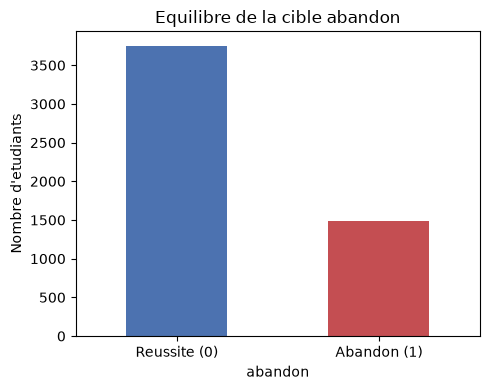

abandon
0    71.58
1    28.42
Name: proportion, dtype: float64

In [36]:
fig, ax = plt.subplots(figsize=(5, 4))
df_eda["abandon"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["Reussite (0)", "Abandon (1)"], rotation=0)
ax.set_title("Equilibre de la cible abandon")
ax.set_ylabel("Nombre d'etudiants")
plt.tight_layout()
plt.show()

df_eda["abandon"].value_counts(normalize=True).mul(100).round(2)


**Interpretation.** La cible est desequilibree mais pas extreme : 71.6 % de reussite contre 28.4 % d'abandon. C'est suffisamment marque pour qu'un modele qui predirait toujours "pas d'abandon" atteigne 71.6 % d'accuracy sans aucune valeur predictive : il faudra evaluer avec le rappel, le F1 ou l'AUC plutot qu'avec la seule accuracy, coherent avec la priorite donnee plus haut a la reduction des faux negatifs.


### Distribution de `moyenne_finale` et lien avec l'abandon


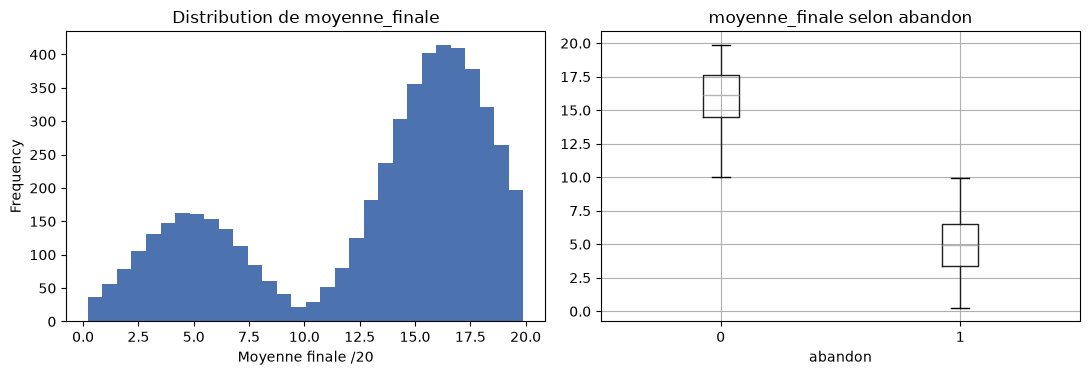

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_eda["moyenne_finale"].plot(kind="hist", bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution de moyenne_finale")
axes[0].set_xlabel("Moyenne finale /20")

df_eda.boxplot(column="moyenne_finale", by="abandon", ax=axes[1])
axes[1].set_title("moyenne_finale selon abandon")
axes[1].set_xlabel("abandon")
plt.suptitle("")
plt.tight_layout()
plt.show()


**Interpretation.** Sans surprise, les etudiants en situation d'abandon (`abandon = 1`) ont une `moyenne_finale` nettement plus basse (correlation de -0.92 avec `abandon`). C'est attendu puisque les deux variables decrivent la meme realite academique en fin de semestre : a ce titre, `moyenne_finale` reste utile pour l'EDA et pour la cible de regression secondaire, mais elle ne doit jamais servir de variable explicative pour predire `abandon` (fuite de donnees deja signalee au chapitre 6.5).


### Correlations avec les variables numeriques disponibles a mi-S1


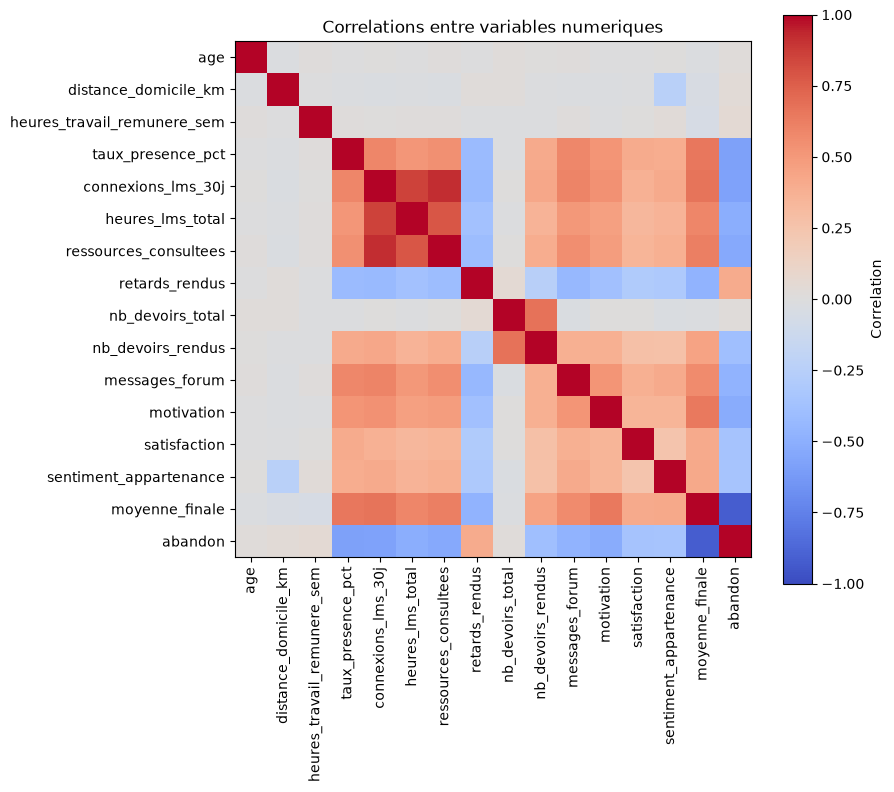

moyenne_finale                -0.918157
taux_presence_pct             -0.578791
connexions_lms_30j            -0.573985
ressources_consultees         -0.536337
motivation                    -0.521174
heures_lms_total              -0.503792
messages_forum                -0.474205
nb_devoirs_rendus             -0.387101
satisfaction                  -0.353333
sentiment_appartenance        -0.349718
nb_devoirs_total               0.021070
age                            0.022501
distance_domicile_km           0.033332
heures_travail_remunere_sem    0.051151
retards_rendus                 0.403059
abandon                        1.000000
Name: abandon, dtype: float64

In [38]:
numeric_cols = [
    "age", "distance_domicile_km", "heures_travail_remunere_sem", "taux_presence_pct",
    "connexions_lms_30j", "heures_lms_total", "ressources_consultees", "retards_rendus",
    "nb_devoirs_total", "nb_devoirs_rendus", "messages_forum", "motivation", "satisfaction",
    "sentiment_appartenance", "moyenne_finale", "abandon",
]
corr = df_eda[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlations entre variables numeriques")
plt.tight_layout()
plt.show()

corr["abandon"].sort_values()


**Interpretation.** En excluant `moyenne_finale` (l'autre cible, pas une feature), les correlations les plus fortes avec `abandon` sont toutes des variables d'engagement mesurables a mi-S1 : `taux_presence_pct` (-0.58), `connexions_lms_30j` (-0.57), `ressources_consultees` (-0.54), `motivation` (-0.52), `heures_lms_total` (-0.50), `messages_forum` (-0.47) et `retards_rendus` (+0.40, seule correlation positive marquee). A l'inverse, `age`, `distance_domicile_km`, `heures_travail_remunere_sem` et `nb_devoirs_total` sont quasiment non correles (< 0.05 en valeur absolue) : ce sont probablement des predicteurs faibles, a confirmer avec l'importance des variables une fois le modele entraine.


### Taux d'abandon par type de bac


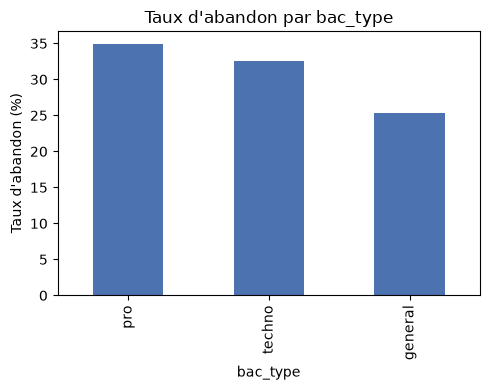

bac_type
pro        34.93
techno     32.55
general    25.38
Name: abandon, dtype: float64

In [39]:
taux_abandon_bac = (df_eda.groupby("bac_type")["abandon"].mean() * 100).round(2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5, 4))
taux_abandon_bac.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Taux d'abandon (%)")
ax.set_title("Taux d'abandon par bac_type")
plt.tight_layout()
plt.show()

taux_abandon_bac


**Interpretation.** Le type de bac est discriminant : 34.9 % d'abandon pour un bac professionnel, 32.6 % pour un bac technologique, contre seulement 25.4 % pour un bac general. Un ecart de pres de 10 points entre `pro` et `general` en fait un candidat feature solide, a encoder en nominal (one-hot) puisqu'il n'y a pas d'ordre naturel entre les 3 filieres de bac.



# 8.7. Préparation des données

## Colonnes non pertinentes pour la modelisation -> dataframe silver

Comme indiqué au chapitre les colonnes suivantes sont supprimées : Suppression des identifiants (RGPD), variables leurres, colonnes a fuite temporelle, ainsi que `sexe` et `boursier`. Resultat enregistre dans un dataframe `df_silver` distinct (le `df_bronze` original n'est pas modifie). Les cibles `abandon` et `moyenne_finale` sont conservees (cette derniere ne devra jamais servir de variable explicative pour predire `abandon`).


In [40]:
SILVER_DIR = Path("data/silver")
SILVER_DIR.mkdir(parents=True, exist_ok=True)

colonnes_a_supprimer = [
    "student_id",
    "id_dossier",
    "annee_universitaire",
    "groupe_td",
    "couleur_carte_etudiante",
    "jour_inscription",
    "moyenne_partiels_s1",
    "nb_ue_total",
    "nb_ue_validees_s1",
    "niveau",
    "commentaire_tuteur",
    "sexe",
    "boursier",
]

df_silver = df_bronze.drop(columns=colonnes_a_supprimer)
df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver.shape


(5240, 26)

## Homogeneisation de la colonne date_inscription (dataframe silver)

Formats melanges dans le CSV source (`AAAA-MM-JJ`, `JJ/MM/AAAA`, `JJ Mon AAAA`). Parsing unifie (jour en premier) puis reecriture au format `JJ-MM-AAAA`, applique uniquement sur `df_silver` (le `df_bronze` original n'est pas modifie).


In [41]:
df_silver["date_inscription"] = pd.to_datetime(
    df_silver["date_inscription"], format="mixed", dayfirst=True
).dt.strftime("%d-%m-%Y")

df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver["date_inscription"].sample(10, random_state=1)


5207    06-09-2024
3321    05-09-2024
280     18-09-2024
4971    06-09-2024
4       04-09-2024
3075    11-09-2024
1247    20-09-2024
200     27-09-2024
4128    18-09-2024
1179    03-09-2024
Name: date_inscription, dtype: object

## Conversion des colonnes numeriques mal typees

Les colonnes `distance_domicile_km` et `taux_presence_pct` sont en `object` a cause d'un melange de virgule decimale et d'unites (`km`, `%`) heritees du CSV source.


In [42]:
for col in ["distance_domicile_km", "taux_presence_pct"]:
    df_silver[col] = (
        df_silver[col]
        .astype(str)
        .str.replace("km", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

n_doublons = df_silver.duplicated().sum()
pct_doublons = n_doublons / len(df_silver) * 100
print(f"Doublons avant suppression : {n_doublons} ({pct_doublons:.2f} %)")

df_silver = df_silver.drop_duplicates().reset_index(drop=True)
df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver.info(verbose=True, show_counts=True)


Doublons avant suppression : 40 (0.76 %)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   filiere                       5200 non-null   object 
 1   age                           5200 non-null   int64  
 2   bac_type                      5200 non-null   object 
 3   mention_bac                   4992 non-null   object 
 4   etablissement_origine         4940 non-null   object 
 5   distance_domicile_km          4888 non-null   float64
 6   heures_travail_remunere_sem   4576 non-null   float64
 7   taux_presence_pct             5200 non-null   float64
 8   connexions_lms_30j            4992 non-null   float64
 9   heures_lms_total              5200 non-null   float64
 10  ressources_consultees         5200 non-null   int64  
 11  retards_rendus                5200 non-null   int64  
 12  nb_devoirs_total     

# Transformation des données

## Homogeneisation de la colonne bac_type (dataframe silver)

Variantes de casse/accents/abreviations (`GEN`, `general`, `Generale`, `General`, `general` accentue, `TECHNO`, `Technologique`, `techno`, `Professionnel`, `pro`, `PRO`, `" pro"`). Normalisation vers 3 categories : `general`, `techno`, `pro`.


In [43]:
s = df_silver["bac_type"].str.strip().str.lower()
s = s.str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("utf-8")

df_silver["bac_type"] = s.mask(s.str.startswith("gen"), "general").mask(s.str.startswith("techno"), "techno").mask(s.str.contains("pro"), "pro")

df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver["bac_type"].value_counts()


bac_type
general    3197
techno     1402
pro         601
Name: count, dtype: int64

## Homogeneisation de la colonne filiere (dataframe silver)

Memes variantes de casse/espaces que pour la jointure bronze. Normalisation vers la casse canonique du catalogue des formations (`Biologie`, `Droit`, `Gestion`, `Informatique`, `Lettres`, `Mathematiques`, `Psychologie`, `STAPS`).


In [44]:
filiere_canonique = {f.lower(): f for f in df_catalogue["filiere"]}
df_silver["filiere"] = df_silver["filiere"].str.strip().str.lower().map(filiere_canonique)

df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver["filiere"].value_counts()


filiere
Informatique     858
Gestion          819
Droit            730
Psychologie      713
Biologie         621
STAPS            550
Mathematiques    485
Lettres          424
Name: count, dtype: int64

## Homogeneisation de la colonne mention_bac (dataframe silver)

Abreviations et casse melangees (`P`/`passable`/`Passable`, `AB`/`ab`/`Assez Bien`, `B`/`Bien`, `TB`/`tres bien`/`Tres Bien`). Normalisation vers 4 categories : `Passable`, `Assez Bien`, `Bien`, `Tres Bien`.

Note : `etablissement_origine` ne contient aucune variante (`lycee_public`, `lycee_prive`, `cfa`, `autre`) et ne necessite pas d'homogeneisation.


In [45]:
s = df_silver["mention_bac"].str.strip().str.lower()
s = s.str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("utf-8")

mapping_mention = {
    "p": "Passable", "passable": "Passable",
    "ab": "Assez Bien", "assez bien": "Assez Bien",
    "b": "Bien", "bien": "Bien",
    "tb": "Tres Bien", "tres bien": "Tres Bien",
}
df_silver["mention_bac"] = s.map(mapping_mention)

df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver["mention_bac"].value_counts(dropna=False)


mention_bac
Passable      1952
Assez Bien    1602
Bien           995
Tres Bien      443
NaN            208
Name: count, dtype: int64

## Taux d'abandon global et par filiere
La classe de détection n'est ni majoritaire, ni trop minoritaire. L'ajout de données "artificielle" (SMOTE) pour un ré-équilibrage n'est pas nécessaire.

In [46]:
print("Taux d'abandon global :", (df_silver["abandon"].mean() * 100).round(2), "%")

taux_abandon_filiere = (
    df_silver.groupby("filiere")["abandon"].mean() * 100
).round(2).sort_values(ascending=False)
taux_abandon_filiere


Taux d'abandon global : 28.44 %


filiere
Gestion          31.14
Droit            29.32
STAPS            29.09
Lettres          28.07
Mathematiques    28.04
Biologie         28.02
Informatique     27.74
Psychologie      25.67
Name: abandon, dtype: float64

## Encodage des variables categorielles (dataframe silver)

L'encodage est nécessaire surtout si on utilise une régression logistique dans la comparaison de modèles (mentionnée dans le résumé exécutif) : un modèle linéaire ne peut pas interpréter des chaînes de caractères, et un simple encodage ordinal (0,1,2...) imposerait un ordre arbitraire et fictif entre les filières. Pour les modèles à arbres (RandomForest, boosting), c'est moins critique mais reste standard pour comparer les familles de modèles sur la même matrice de caractéristiques.

Application à :

- **`mention_bac`** (ordinale, `Passable < Assez Bien < Bien < Tres Bien`) : encodage ordinal `{0, 1, 2, 3}`. Les valeurs manquantes restent `NaN` (l'imputation reelle se fera plus tard, apres le split train/test, pour eviter toute fuite).
- **`filiere`, `bac_type`, `faculte`** (nominales, sans valeur manquante) : one-hot encoding classique (`pd.get_dummies`), sans colonne `_nan` puisqu'aucune de ces colonnes ne contient de valeur manquante.
- **`etablissement_origine`** (nominale, ~5 % de manquants) : one-hot encoding avec `dummy_na=True`, ce qui cree une colonne indicatrice `etablissement_origine_nan` explicite. Cette colonne n'est pas une imputation (aucune valeur n'est devinee) : elle rend simplement la non-reponse visible comme un signal potentiel, en coherence avec le choix fait de reporter toute imputation statistique apres le split.



In [47]:
mapping_ordinal = {"Passable": 0, "Assez Bien": 1, "Bien": 2, "Tres Bien": 3}
df_silver["mention_bac"] = df_silver["mention_bac"].map(mapping_ordinal)

colonnes_nominales_completes = ["filiere", "bac_type", "faculte"]
df_silver = pd.get_dummies(df_silver, columns=colonnes_nominales_completes)

df_silver = pd.get_dummies(df_silver, columns=["etablissement_origine"], dummy_na=True)

bool_cols = df_silver.select_dtypes(include="bool").columns
df_silver[bool_cols] = df_silver[bool_cols].astype(int)

df_silver.to_csv(SILVER_DIR / "silver_dataset.csv", index=False, sep=";")
df_silver.shape


(5200, 44)

## Bilan des valeurs nulles par colonne (dataframe silver)


In [48]:
bilan_nulls = pd.DataFrame({
    "n_nulls": df_silver.isna().sum(),
    "pct_nulls": (df_silver.isna().sum() / len(df_silver) * 100).round(2),
}).sort_values("n_nulls", ascending=False)
bilan_nulls = bilan_nulls[bilan_nulls["n_nulls"] > 0]
bilan_nulls


,n_nulls,pct_nulls
heures_travail_remunere_sem,624,12.0
satisfaction,416,8.0
sentiment_appartenance,364,7.0
distance_domicile_km,312,6.0
motivation,260,5.0
mention_bac,208,4.0
connexions_lms_30j,208,4.0


La proportion de valeurs nulles n'est pas trop importante. On va pouvoir utiliser des méthodes de remplissage afin d'obtenir un dataframe sans aucune valeurs nulles.

## Strategie d'imputation des valeurs nulles (dataframe silver)

`heures_travail_remunere_sem` et `connexions_lms_30j` contiennent deja beaucoup de vrais 0 parmi les valeurs non nulles : un NaN represente donc une non-reponse reelle, pas un 0 implicite. Cela ecarte une imputation par 0.

| Colonne | Type | Methode envisagee | Pourquoi |
|---|---|---|---|
| `heures_travail_remunere_sem` | numerique continue | mediane | distribution asymetrique (beaucoup de 0, quelques valeurs hautes) ; mediane robuste aux outliers |
| `connexions_lms_30j` | numerique discrete | mediane | idem, comptage non symetrique |
| `distance_domicile_km` | numerique continue | mediane | pas de lien attendu avec le decrochage, imputation simple suffit |
| `satisfaction`, `sentiment_appartenance`, `motivation` | ordinales (1-5, auto-evaluation) | mediane + indicateur binaire `_manquant` | la non-reponse a ces questionnaires d'engagement peut elle-meme etre correlee au decrochage ; le flag conserve ce signal plutot que de l'imputer en silence |
| `etablissement_origine` | categorielle | nouvelle categorie `"Inconnu"` | evite affecter artificiellement la donnée majoritaire (`lycee_public`) sur des cas où on ne sait rien |
| `mention_bac` | categorielle ordinale | nouvelle categorie `"Inconnue"` | meme logique, coherent avec les autres categories deja nettoyees |

**Point d'attention (anti-fuite) :** l'imputation (mediane) devra etre calculée uniquement sur le train (jeux d'entrainement) puis appliquée au test, pas sur l'ensemble du dataset en une seule fois.


# 7. Dataframe gold


## Feature engineering : taux de rendu des devoirs

Calcul du `taux_rendu = nb_devoirs_rendus / nb_devoirs_total`. Si la valeur maximum est de 1 cela veut dire que la colonne nb_devoirs_rendus est renseignée en fin de semestre, elle est donc à supprimer pour éviter une fuite de données.
Creation de `df_gold` a partir de `df_silver` (celui-ci reste inchange). Ajout de `taux_rendu = nb_devoirs_rendus / nb_devoirs_total`, puis suppression des deux colonnes sources (redondantes une fois le ratio calcule).

## Verification : maximum du taux de rendu


In [49]:
ratio = df_silver["nb_devoirs_rendus"] / df_silver["nb_devoirs_total"]

print(f"maximum du taux de rendu : {ratio.max()} ")


maximum du taux de rendu : 1.0 


Si le ratio max = 1, on n'ajoute pas de colonne pour le taux de ration et on supprime la colonne  `nb_devoirs_rendus` pour éviter les fuites de données . On crée ensuite le gold dataset. 

Comme indiqué plus haut, le golddataset sera imputer pour remplacer les NaN par des valeurs cohérentes divisées entre le jeu d'entrainenement (train) et à part le jeu de test.

In [50]:
GOLD_DIR = Path("data/gold")
GOLD_DIR.mkdir(parents=True, exist_ok=True)

df_gold = df_silver.copy()
# seuil arbitraire
if ratio.max() < 1 :
    df_gold["taux_rendu"] = df_gold["nb_devoirs_rendus"] / df_gold["nb_devoirs_total"]
    df_gold = df_gold.drop(columns=["nb_devoirs_rendus"])

df_gold = df_gold.drop(columns=["nb_devoirs_total"])
df_gold.to_csv(GOLD_DIR / "gold-dataset.csv", index=False, sep=";")
print(f"fichier gold créé : {GOLD_DIR / "gold-dataset.csv"} ")

fichier gold créé : data\gold\gold-dataset.csv 


# 8. Split train/test et imputation


## Split puis imputation (fit sur le train uniquement)

Comme discute precedemment, l'imputation des 7 colonnes numeriques restant a NaN (`heures_travail_remunere_sem`, `satisfaction`, `sentiment_appartenance`, `distance_domicile_km`, `motivation`, `mention_bac`, `connexions_lms_30j`) doit etre calculee uniquement sur le train pour eviter toute fuite train/test. Le split est donc fait avant, stratifie sur `abandon` (cible principale), puis `SimpleImputer(strategy="median")` est `fit` sur `df_gold_train` et applique (`transform`) au train et au test avec les memes valeurs.


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df_gold_train, df_gold_test = train_test_split(
    df_gold, test_size=0.2, random_state=42, stratify=df_gold["abandon"]
)

colonnes_a_imputer = [
    "heures_travail_remunere_sem", "satisfaction", "sentiment_appartenance",
    "distance_domicile_km", "motivation", "mention_bac", "connexions_lms_30j",
]

imputer = SimpleImputer(strategy="median")
df_gold_train[colonnes_a_imputer] = imputer.fit_transform(df_gold_train[colonnes_a_imputer])
df_gold_test[colonnes_a_imputer] = imputer.transform(df_gold_test[colonnes_a_imputer])

df_gold_train.to_csv(GOLD_DIR / "gold-dataset-train.csv", index=False, sep=";")
df_gold_test.to_csv(GOLD_DIR / "gold-dataset-test.csv", index=False, sep=";")

print("train:", df_gold_train.shape, "- nulls:", df_gold_train.isna().sum().sum())
print("test:", df_gold_test.shape, "- nulls:", df_gold_test.isna().sum().sum())


train: (4160, 43) - nulls: 0
test: (1040, 43) - nulls: 0


# 9.8. Choix du modèle et démarche scientifique

Comme nous l'avons vu jusque là, c'est un problème de prédiction par classification.

## Comparaison de plusieurs modeles (classification `abandon`)

Plutot qu'un choix figue a priori, comparaison de 3 familles evoquees dans le resume executif : **regression logistique** (baseline interpretable, avec mise a l'echelle des variables), **Random Forest** et **Gradient Boosting** (arbres, pas de mise a l'echelle necessaire). `class_weight="balanced"` compense le desequilibre de la cible (28 % d'abandon) pour la logistique et la Random Forest. `date_inscription` est exclue (texte, pas encore transformee en feature numerique) ainsi que `moyenne_finale` (fuite : c'est l'autre cible).


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

colonnes_exclues = ["abandon", "moyenne_finale", "date_inscription"]
features = [c for c in df_gold_train.columns if c not in colonnes_exclues]

X_train, y_train = df_gold_train[features], df_gold_train["abandon"]
X_test, y_test = df_gold_test[features], df_gold_test["abandon"]

modeles = {
    "Regression logistique": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

resultats = []
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    resultats.append({
        "modele": nom,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

comparaison = pd.DataFrame(resultats).set_index("modele").round(3).sort_values("recall", ascending=False)
comparaison


,accuracy,precision,recall,f1,roc_auc
modele,,,,,
Regression logistique,0.873,0.724,0.895,0.801,0.946
Random Forest,0.868,0.746,0.814,0.779,0.938
Gradient Boosting,0.873,0.791,0.753,0.772,0.939


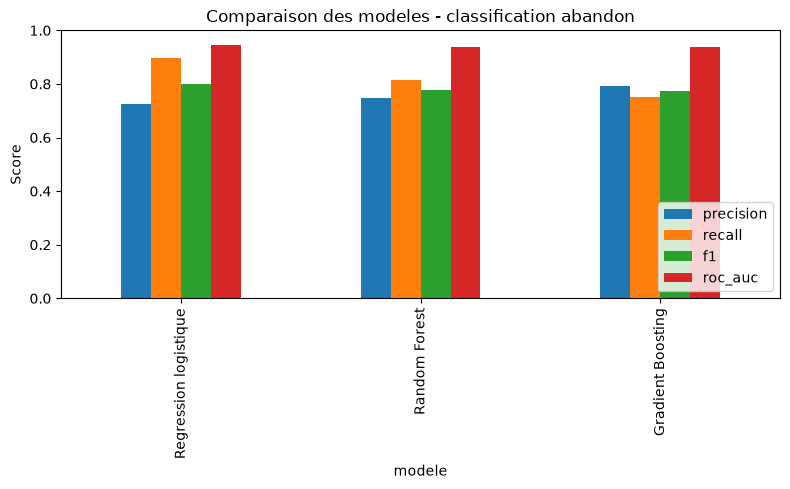

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
comparaison[["precision", "recall", "f1", "roc_auc"]].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Comparaison des modeles - classification abandon")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Interpretation.** Sur ce jeu de donnees, la **regression logistique** obtient le meilleur rappel (0.895) et le meilleur ROC-AUC (0.946), devant Random Forest (rappel 0.814, AUC 0.938) et Gradient Boosting (rappel 0.753, AUC 0.939). C'est coherent avec l'analyse de correlation du chapitre 7.6 : les variables les plus predictives (`taux_presence_pct`, `connexions_lms_30j`, `ressources_consultees`...) ont une relation globalement lineaire avec `abandon`, ce qui avantage un modele lineaire face a des arbres qui n'apportent pas d'interactions non-lineaires supplementaires ici. Etant donne la priorite donnee a la reduction des faux negatifs (rappel), la regression logistique est pour l'instant le meilleur candidat, avec l'avantage supplementaire d'etre nativement interpretable (coefficients) plutot que de necessiter SHAP.

Cette comparaison reste a affiner : validation croisee plutot qu'un seul split, recherche d'hyperparametres (`GridSearchCV`/`RandomizedSearchCV`), et ajustement du seuil de decision (actuellement 0.5) en fonction du cout metier d'un faux negatif discute au chapitre 2/3.


### Matrices de confusion des 3 modeles


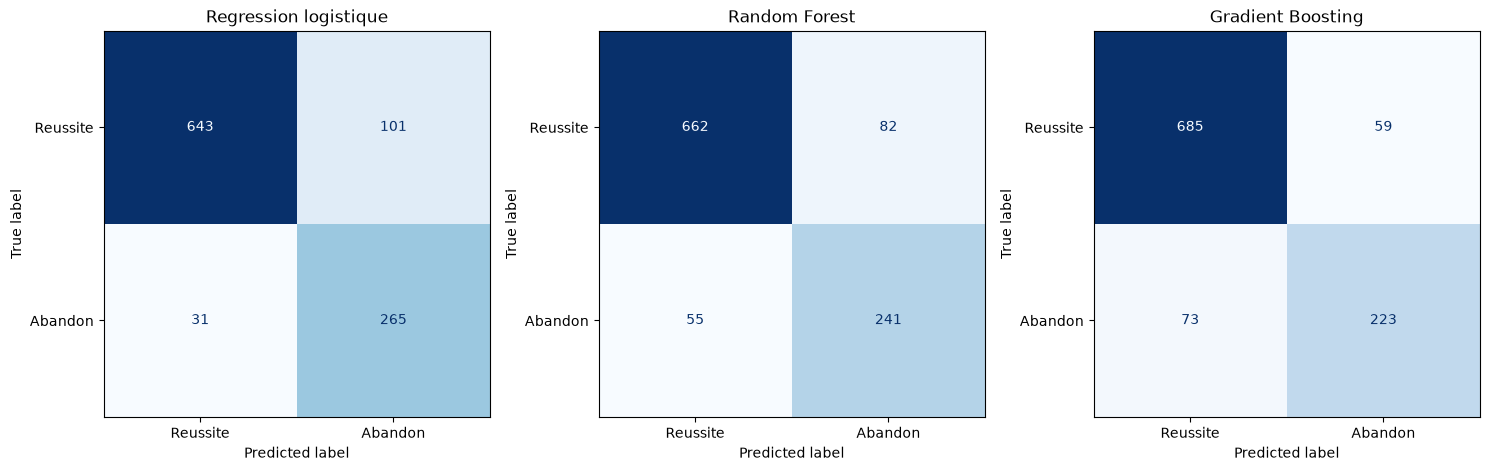

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nom, modele) in zip(axes, modeles.items()):
    ConfusionMatrixDisplay.from_estimator(
        modele, X_test, y_test,
        display_labels=["Reussite", "Abandon"], cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(nom)
plt.tight_layout()
plt.show()


**Interpretation.** La regression logistique fait le moins de faux negatifs (31 etudiants a risque non detectes, contre 55 pour Random Forest et 73 pour Gradient Boosting sur 1040 lignes de test), coherent avec son meilleur rappel (0.895). En contrepartie elle genere plus de faux positifs (101, contre 82 et 59), donc plus d'etudiants signales a tort. C'est l'arbitrage recall/precision deja discute au chapitre 2/3 : etant donne la priorite donnee au cout d'un faux negatif, ce compromis va dans le sens souhaite pour la regression logistique.


### Courbes ROC et Precision-Recall des 3 modeles


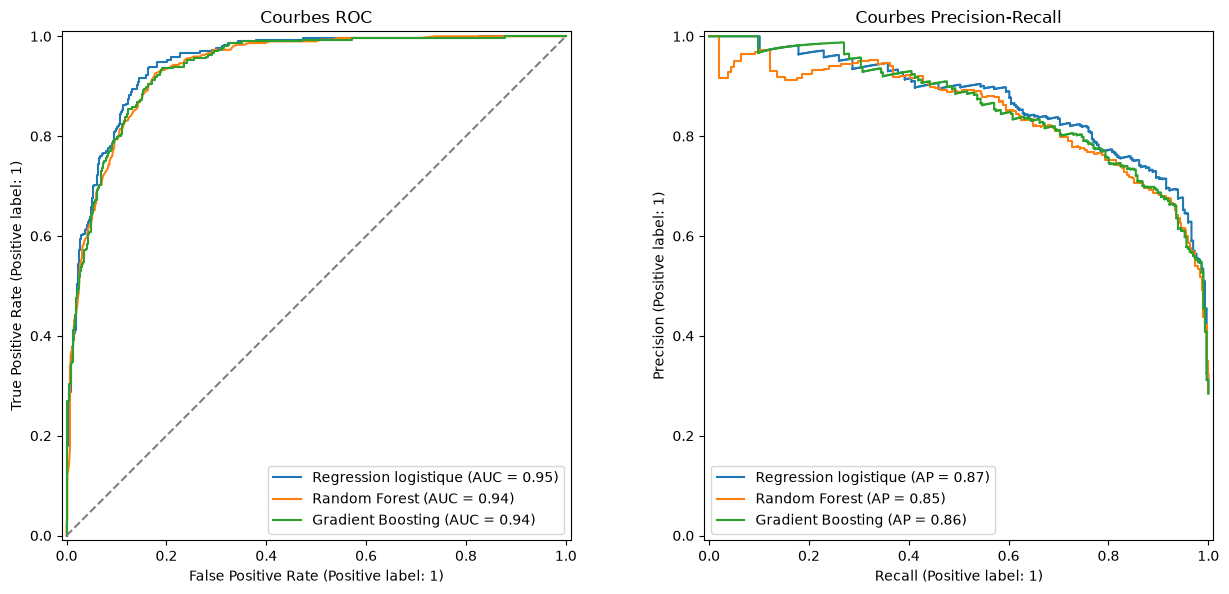

In [55]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for nom, modele in modeles.items():
    RocCurveDisplay.from_estimator(modele, X_test, y_test, name=nom, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_title("Courbes ROC")

for nom, modele in modeles.items():
    PrecisionRecallDisplay.from_estimator(modele, X_test, y_test, name=nom, ax=axes[1])
axes[1].set_title("Courbes Precision-Recall")

plt.tight_layout()
plt.show()


**Interpretation.** La courbe ROC confirme l'AUC : la regression logistique (0.946) domine legerement Gradient Boosting (0.939) et Random Forest (0.938) sur presque toute la plage de seuils, mais l'ecart reste faible. La courbe Precision-Recall est plus parlante ici compte tenu du desequilibre de la cible (28 % d'abandon) : elle montre le compromis reel entre detecter plus d'abandons (rappel) et limiter les fausses alertes (precision), et confirme que la regression logistique conserve un meilleur rappel a precision egale sur la majorite de la courbe. C'est cette courbe, plus que le ROC, qui devrait guider le choix final du seuil de decision en fonction du cout metier d'un faux negatif.


### Courbe seuil-vs-metriques (choix du seuil de decision)

Precision, rappel et F1 traces en fonction du seuil de decision (au lieu du seuil implicite de 0.5 utilise jusqu'ici), pour les 3 modeles. Objectif : visualiser le compromis reel avant de fixer un seuil de production, en coherence avec la priorite donnee au cout d'un faux negatif.


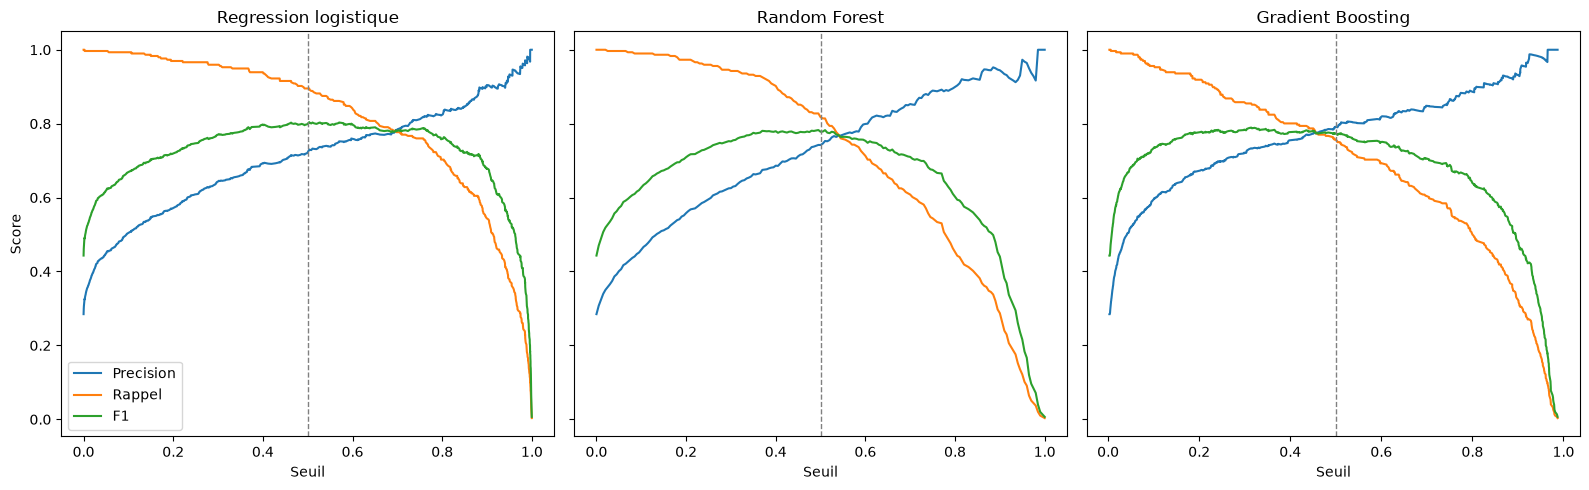

In [56]:
import numpy as np
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (nom, modele) in zip(axes, modeles.items()):
    y_proba = modele.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    ax.plot(thresholds, precision[:-1], label="Precision")
    ax.plot(thresholds, recall[:-1], label="Rappel")
    ax.plot(thresholds, f1[:-1], label="F1")
    ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
    ax.set_title(nom)
    ax.set_xlabel("Seuil")
axes[0].set_ylabel("Score")
axes[0].legend()
plt.tight_layout()
plt.show()


In [57]:
# Deux seuils indicatifs pour la regression logistique (modele retenu)
y_proba = modeles["Regression logistique"].predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

seuil_max_f1 = thresholds[np.argmax(f1[:-1])]
print(f"Seuil qui maximise le F1 : {seuil_max_f1:.3f} (F1 = {f1.max():.3f})")

idx_rappel_95 = np.where(recall[:-1] >= 0.95)[0]
if len(idx_rappel_95):
    s = thresholds[idx_rappel_95[-1]]
    p = precision[idx_rappel_95[-1]]
    print(f"Seuil pour un rappel >= 0.95 : {s:.3f} (precision correspondante = {p:.3f})")


Seuil qui maximise le F1 : 0.503 (F1 = 0.804)
Seuil pour un rappel >= 0.95 : 0.329 (precision correspondante = 0.653)


**Interpretation.** Pour la regression logistique, le seuil qui maximise le F1 (0.503) est quasiment identique au seuil par defaut (0.5) : les metriques deja calculees plus haut n'etaient donc pas defavorisees par un choix de seuil arbitraire. Mais si l'objectif est de pousser le rappel a 0.95 (rater seulement 5 % des abandons reels, coherent avec la priorite donnee au cout d'un faux negatif), il faut baisser le seuil a environ **0.33** : la precision tombe alors a ~0.65, donc davantage de fausses alertes (plus de tutorat declenche pour des etudiants qui n'en avaient pas besoin). Le choix final entre ces deux seuils (ou une valeur intermediaire) devrait etre valide avec la Direction de la reussite etudiante, qui est la seule a pouvoir chiffrer le cout reel d'un faux negatif vs celui d'un faux positif.


### Courbes de calibration

Verifie si la probabilite predite (`predict_proba`) reflete la vraie frequence observee : utile car le choix du seuil de decision, discute au chapitre precedent, ne veut dire quelque chose que si les probabilites sont fiables.


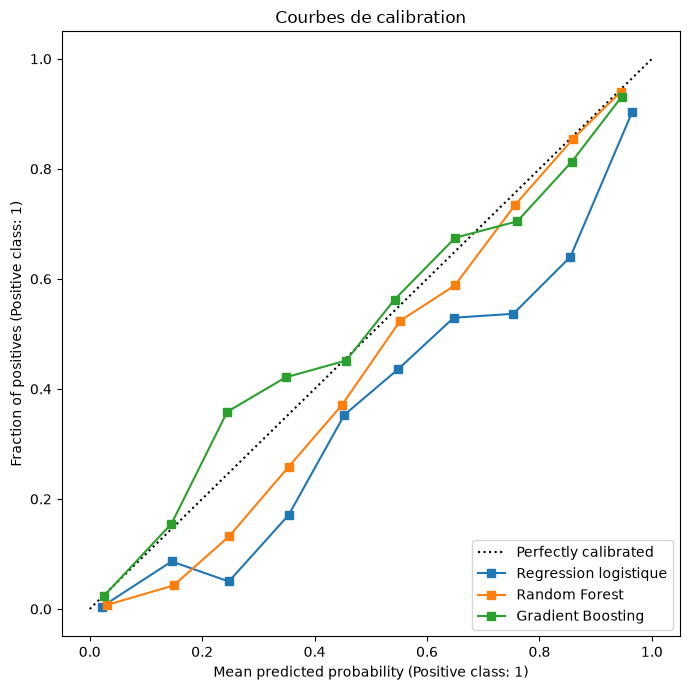

Regression logistique - Brier score : 0.0935
Random Forest - Brier score : 0.0930
Gradient Boosting - Brier score : 0.0898


In [58]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(7, 7))
for nom, modele in modeles.items():
    CalibrationDisplay.from_estimator(modele, X_test, y_test, n_bins=10, name=nom, ax=ax)
ax.set_title("Courbes de calibration")
plt.tight_layout()
plt.show()

for nom, modele in modeles.items():
    proba = modele.predict_proba(X_test)[:, 1]
    print(f"{nom} - Brier score : {brier_score_loss(y_test, proba):.4f}")


**Interpretation.** Les 3 modeles sont assez proches en calibration (Brier score entre 0.090 et 0.094, plus bas = meilleur), Gradient Boosting legerement devant. Point d'attention pour la regression logistique et Random Forest : `class_weight="balanced"` a ete utilise pour compenser le desequilibre de la cible et ameliorer le rappel, mais cela deforme mecaniquement les probabilites predites (elles ne refletent plus le vrai taux de base de 28.4 % d'abandon, seulement un ordre relatif de risque). Consequence pratique : les seuils calcules au chapitre precedent (0.503 pour le F1, 0.33 pour un rappel de 0.95) sont valides *pour ce modele pondere*, mais ne seraient plus les bons si on entrainait sans `class_weight="balanced"` ou si on recalibrait les probabilites (`CalibratedClassifierCV`). A garder en tete avant de figer un seuil de production.


## Validation croisee et optimisation des hyperparametres

Avant de calculer l'importance des variables (qui n'a de sens que sur un modele stable et tune), deux etapes : (1) verifier que l'ecart observe plus haut entre les 3 modeles n'est pas un artefact du seul split train/test utilise jusqu'ici, via une validation croisee 5-fold sur le train ; (2) optimiser les hyperparametres de chaque modele (recherche sur `roc_auc`, metrique la plus robuste au desequilibre de la cible) avant de re-evaluer sur le test.


### Stabilite par validation croisee (modeles par defaut)


Regression logistique: AUC=0.947 +/- 0.006  Recall=0.880 +/- 0.016
Random Forest: AUC=0.939 +/- 0.007  Recall=0.802 +/- 0.032
Gradient Boosting: AUC=0.942 +/- 0.007  Recall=0.762 +/- 0.020


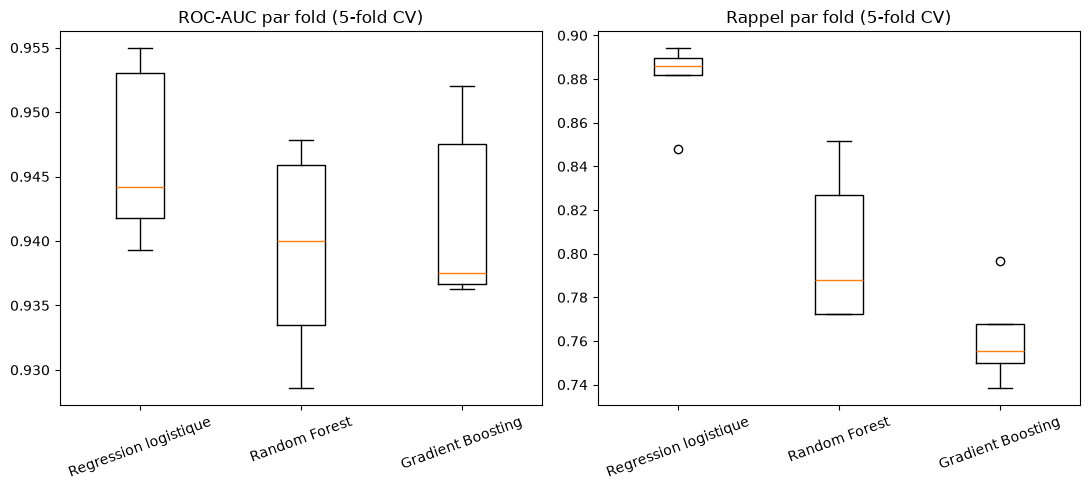

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_cv = {}
for nom, modele in modeles.items():
    resultats_cv = cross_validate(modele, X_train, y_train, cv=cv, scoring=["roc_auc", "recall"], n_jobs=-1)
    scores_cv[nom] = resultats_cv
    print(f"{nom}: AUC={resultats_cv['test_roc_auc'].mean():.3f} +/- {resultats_cv['test_roc_auc'].std():.3f}"
          f"  Recall={resultats_cv['test_recall'].mean():.3f} +/- {resultats_cv['test_recall'].std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].boxplot([scores_cv[nom]["test_roc_auc"] for nom in modeles])
axes[0].set_xticklabels(modeles.keys(), rotation=20)
axes[0].set_title("ROC-AUC par fold (5-fold CV)")

axes[1].boxplot([scores_cv[nom]["test_recall"] for nom in modeles])
axes[1].set_xticklabels(modeles.keys(), rotation=20)
axes[1].set_title("Rappel par fold (5-fold CV)")

plt.tight_layout()
plt.show()


**Interpretation.** Les ecarts-types sont faibles (AUC : +/-0.006 a +/-0.007 ; rappel : +/-0.016 a +/-0.032 selon le modele) et les boites ne se superposent pas : l'avance de la regression logistique sur le rappel n'est donc pas un artefact du split choisi (`random_state=42`), elle se confirme sur les 5 folds.


### Optimisation des hyperparametres (recherche sur ROC-AUC)


In [60]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

grille_logistique = {"clf__C": [0.01, 0.1, 1, 10]}
recherche_log = GridSearchCV(
    modeles["Regression logistique"], grille_logistique, cv=cv, scoring="roc_auc", n_jobs=-1
)
recherche_log.fit(X_train, y_train)

grille_rf = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 3, 5],
}
recherche_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    grille_rf, n_iter=10, cv=cv, scoring="roc_auc", random_state=42, n_jobs=-1
)
recherche_rf.fit(X_train, y_train)

grille_gb = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
}
recherche_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    grille_gb, n_iter=10, cv=cv, scoring="roc_auc", random_state=42, n_jobs=-1
)
recherche_gb.fit(X_train, y_train)

for nom, recherche in [
    ("Regression logistique", recherche_log),
    ("Random Forest", recherche_rf),
    ("Gradient Boosting", recherche_gb),
]:
    print(f"{nom} - meilleurs parametres : {recherche.best_params_} "
          f"(AUC cv = {recherche.best_score_:.3f})")


Regression logistique - meilleurs parametres : {'clf__C': 0.01} (AUC cv = 0.947)
Random Forest - meilleurs parametres : {'n_estimators': 100, 'min_samples_leaf': 3, 'max_depth': 10} (AUC cv = 0.939)
Gradient Boosting - meilleurs parametres : {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05} (AUC cv = 0.942)


### Re-evaluation des modeles tunes sur le test


In [61]:
modeles_tunes = {
    "Regression logistique": recherche_log.best_estimator_,
    "Random Forest": recherche_rf.best_estimator_,
    "Gradient Boosting": recherche_gb.best_estimator_,
}

resultats_tunes = []
for nom, modele in modeles_tunes.items():
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    resultats_tunes.append({
        "modele": nom,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

comparaison_tunee = pd.DataFrame(resultats_tunes).set_index("modele").round(3).sort_values("recall", ascending=False)
comparaison_tunee


,precision,recall,f1,roc_auc
modele,,,,
Regression logistique,0.729,0.899,0.805,0.946
Random Forest,0.725,0.865,0.789,0.941
Gradient Boosting,0.796,0.740,0.767,0.941


**Interpretation.** Apres tuning, le classement ne change pas : la regression logistique reste devant (recall 0.899, AUC 0.946 sur le test), avec un `C=0.01` optimal (forte regularisation), coherent avec la presence de variables correlees entre elles identifiee au chapitre 7.6. Random Forest et Gradient Boosting s'ameliorent legerement par rapport a leurs versions par defaut mais ne rattrapent pas la logistique. Conclusion : le choix de la regression logistique (tunee) est confirme, et ce n'est plus base sur un seul split mais sur une validation croisee stable. Les etapes suivantes (importance des variables, seuil final) peuvent maintenant s'appuyer sur `modeles_tunes["Regression logistique"]` plutot que sur la version par defaut.


## Importance des variables / coefficients (modeles tunes)

Calculee maintenant que les modeles sont tunes et valides par validation croisee (chapitre precedent), pour verifier l'explicabilite et la coherence avec les correlations trouvees en EDA (7.6). Pour la regression logistique : coefficients signes (positif = augmente le risque d'abandon, negatif = le diminue), lisibles directement car les features sont standardisees. Pour Random Forest et Gradient Boosting : importance par reduction d'impurite (sans signe).


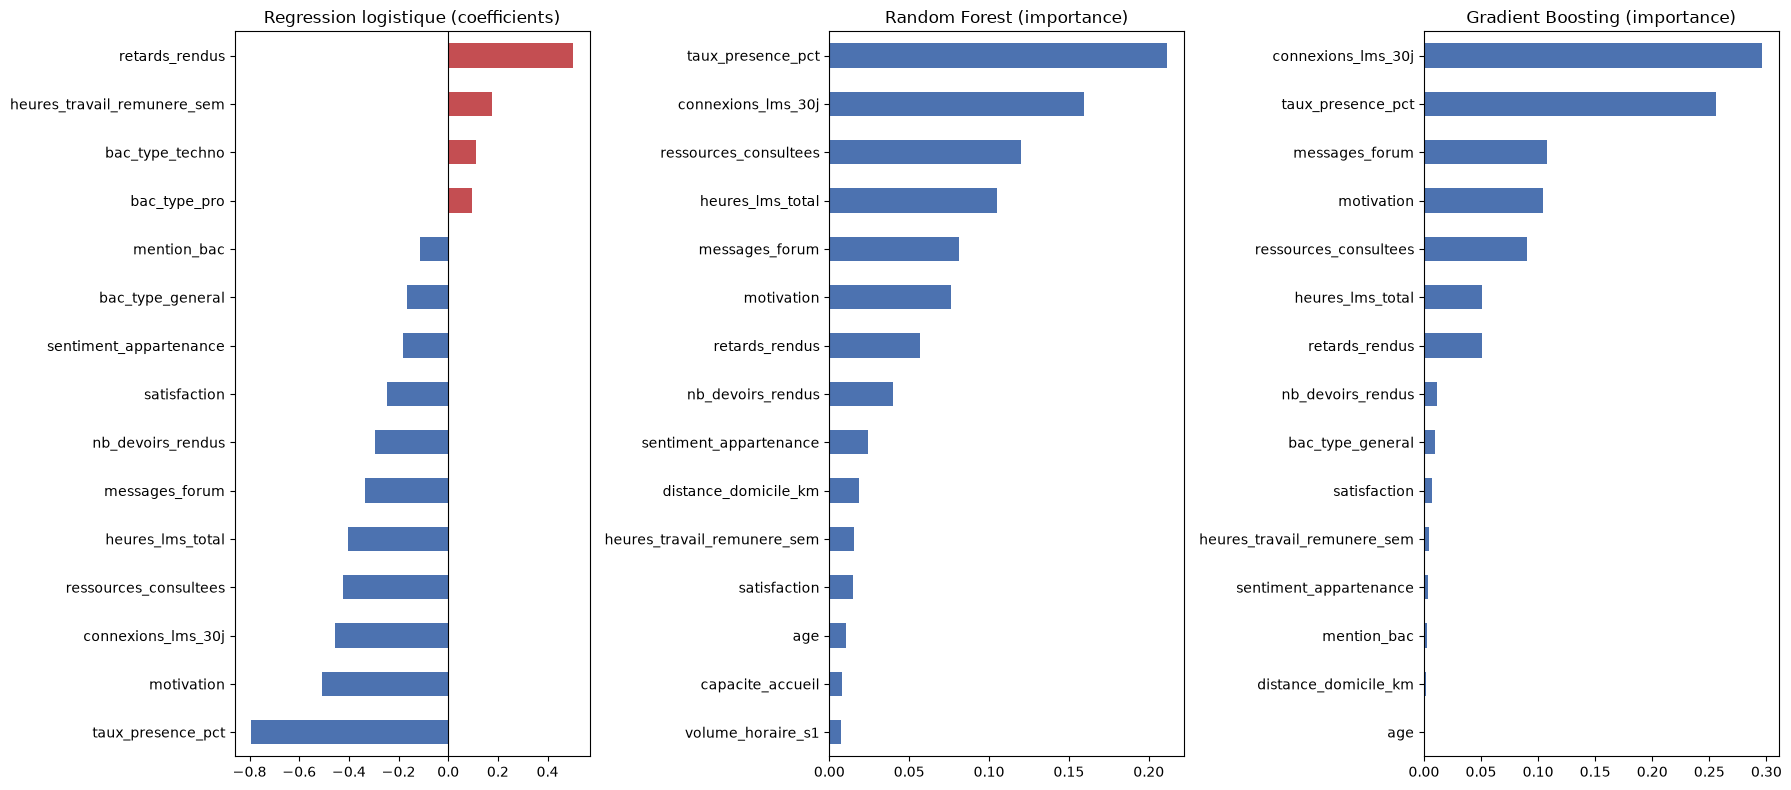

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

coefs = pd.Series(modeles_tunes["Regression logistique"].named_steps["clf"].coef_[0], index=features)
coefs_top = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index).sort_values()
coefs_top.plot(
    kind="barh", ax=axes[0],
    color=coefs_top.apply(lambda v: "#C44E52" if v > 0 else "#4C72B0"),
)
axes[0].set_title("Regression logistique (coefficients)")
axes[0].axvline(0, color="black", linewidth=0.8)

for ax, nom in zip(axes[1:], ["Random Forest", "Gradient Boosting"]):
    imp = (
        pd.Series(modeles_tunes[nom].feature_importances_, index=features)
        .sort_values(ascending=False).head(15).sort_values()
    )
    imp.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(nom + " (importance)")

plt.tight_layout()
plt.show()


**Interpretation.** Les 3 modeles s'accordent sur l'essentiel : `taux_presence_pct`, `connexions_lms_30j`, `ressources_consultees`, `motivation`, `heures_lms_total` et `messages_forum` figurent dans le top des 3 classements. C'est exactement les variables d'engagement identifiees comme les plus correlees a `abandon` en EDA (7.6), ce qui renforce la confiance dans le modele (pas d'appui sur une variable inattendue ou une fuite residuelle). `retards_rendus` a un coefficient positif marque (+0.50) pour la logistique : c'est la seule variable qui *augmente* le risque, coherent avec le signe positif deja observe en correlation (+0.40). Aucune variable administrative ou leurre (`age`, `distance_domicile_km`, `faculte_*`, `filiere_*`) n'apparait dans le top 15 d'aucun des 3 modeles : elles peuvent etre presentees comme peu utiles au modele, ce qui simplifie le message aux equipes pedagogiques (l'engagement compte, pas le profil socio-demographique).

Sur le plan de l'explicabilite (exigence du cadrage metier, chapitre 5.4) : les coefficients de la regression logistique retenue peuvent deja etre presentes directement aux enseignants ("la presence en cours et l'activite sur le LMS sont les signaux les plus forts"). Le diagramme SHAP ci-dessous confirme ce classement et ajoute une explication instance par instance (utile pour justifier une alerte sur un etudiant precis, pas seulement au niveau global du modele).


### Diagramme SHAP (regression logistique retenue)


Background dataset has 4160 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4160 when initializing the masker.


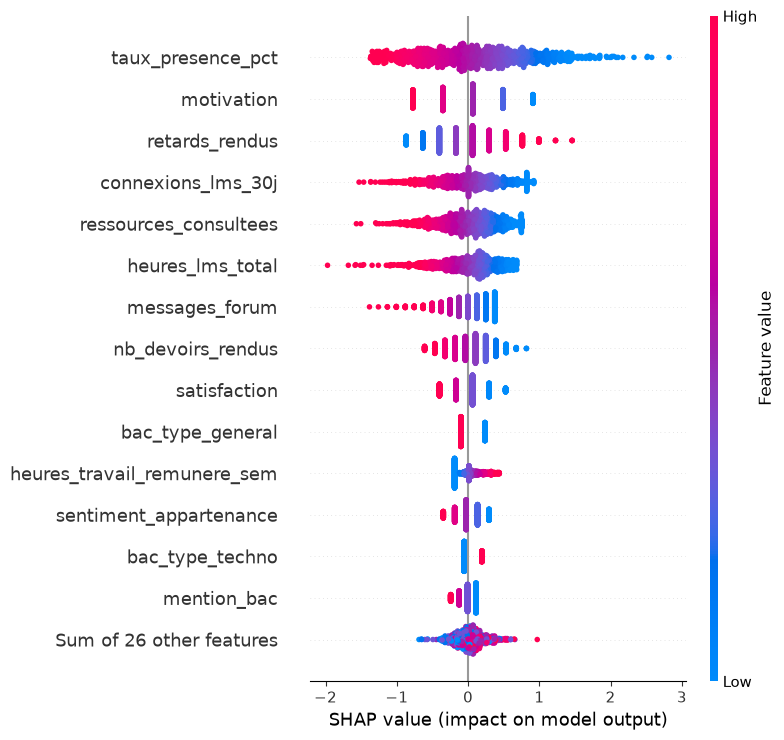

In [63]:
import shap

scaler = modeles_tunes["Regression logistique"].named_steps["scaler"]
clf = modeles_tunes["Regression logistique"].named_steps["clf"]

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features)

explainer = shap.LinearExplainer(clf, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()


**Interpretation.** Le classement SHAP (importance moyenne absolue) confirme celui des coefficients : `taux_presence_pct` domine largement, suivie de `motivation`, `retards_rendus`, `connexions_lms_30j`, `ressources_consultees`, `heures_lms_total`, `messages_forum` puis `satisfaction`. Le diagramme beeswarm ajoute une information que le coefficient seul ne donne pas : pour `taux_presence_pct`, les points rouges (valeurs elevees de la variable) sont concentres a gauche (SHAP negatif, risque plus faible) et les points bleus (valeurs faibles) a droite (SHAP positif, risque plus eleve), de facon tres nette et sans inversion - la relation est bien monotone et homogene sur toute la plage de valeurs, ce qui justifie a posteriori l'usage d'un modele lineaire plutot que des arbres pour ce jeu de donnees.

En pratique, ce diagramme permettrait d'expliquer une prediction individuelle a un enseignant ("cet etudiant est signale a risque principalement a cause de sa faible presence et de ses retards de rendu") plutot que de se limiter a une explication globale du modele.


## Modele retenu : regression logistique

**La regression logistique tunee** (`C=0.01`, `class_weight="balanced"`) est le modele retenu.

**Pourquoi elle l'emporte sur les 3 criteres qui comptent ici :**
- **Performance** : meilleur rappel (0.899) et meilleur AUC (0.946 test, 0.947 en CV), confirme sur 5 folds donc pas un artefact de split, et confirme apres tuning des 3 modeles.
- **Alignement metier** : le rappel le plus eleve = moins de faux negatifs (31 vs 55-73 pour RF/GB) - exactement la priorite fixee au chapitre 2/3 (cout d'un faux negatif > cout d'un faux positif).
- **Explicabilite** : coefficients directement lisibles et presentables aux equipes pedagogiques (5.4), sans necessiter SHAP, et coherents avec l'EDA (les variables d'engagement dominent, aucune variable demographique/leurre en tete).

**Le compromis assume :** elle genere plus de faux positifs (precision 0.729 vs 0.796 pour Gradient Boosting) - plus d'etudiants signales a tort, donc plus de tutorat declenche pour des profils qui n'en avaient pas besoin. Vu la priorite donnee aux faux negatifs, ce compromis va dans le bon sens.


## Suivi des configurations avec MLflow

Plutot que de garder les comparaisons de modeles/hyperparametres uniquement dans la sortie des cellules, chaque configuration testee (modele par defaut, puis modele tune) est journalisee comme un run MLflow : parametres, metriques de test, et le modele final (regression logistique tunee) avec sa signature. Meme convention que `scripts/demo_versioning.py` (backend SQLite, necessaire pour le Model Registry).


In [64]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("decrochage-abandon-classification")


<Experiment: artifact_location='file:C:/Formation IA/Examen/ProjetDecrochage/mlruns/1', creation_time=1785762626895, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785762626895, lifecycle_stage='active', name='decrochage-abandon-classification', tags={}, trace_location=None, workspace='default'>

### Journalisation des configurations par defaut (baseline)


In [65]:
configs_baseline = {
    "Regression logistique": {"C": 1.0, "class_weight": "balanced"},
    "Random Forest": {"n_estimators": 200, "class_weight": "balanced"},
    "Gradient Boosting": {},
}

for nom, modele in modeles.items():
    with mlflow.start_run(run_name=f"{nom} - baseline"):
        mlflow.set_tags({"modele": nom, "stage": "baseline"})
        mlflow.log_params(configs_baseline[nom])
        y_pred = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)[:, 1]
        mlflow.log_metrics({
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
        })


### Journalisation des configurations tunees, et enregistrement du modele retenu


In [66]:
recherches = {
    "Regression logistique": recherche_log,
    "Random Forest": recherche_rf,
    "Gradient Boosting": recherche_gb,
}

for nom, recherche in recherches.items():
    modele = recherche.best_estimator_
    with mlflow.start_run(run_name=f"{nom} - tune") as run:
        mlflow.set_tags({"modele": nom, "stage": "tune"})
        mlflow.log_params(recherche.best_params_)
        mlflow.log_metric("auc_cv", recherche.best_score_)
        y_pred = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)[:, 1]
        mlflow.log_metrics({
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
        })
        if nom == "Regression logistique":
            signature = infer_signature(X_test, y_proba)
            try:
                mlflow.sklearn.log_model(
                    modele, name="model", signature=signature,
                    input_example=X_test.head(2),
                    registered_model_name="decrochage-abandon-logistique",
                )
            except Exception as exc:
                print(f"[i] enregistrement au registre indisponible : {exc}")
                mlflow.sklearn.log_model(modele, name="model", signature=signature)
            print(f"run retenu : {run.info.run_id}")


c:\Formation IA\Examen\ProjetDecrochage\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/03 15:20:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Formation IA\Examen\ProjetDecrochage
2026/08/03 15:20:54 INFO mlflow.utils.uv_utils: Detected uv project: found uv.l

run retenu : a283452046514730a0290bcdb0a0240d


**Interpretation.** 6 runs sont journalises (3 modeles x baseline/tune), comparables dans l'UI MLflow (`uv run mlflow ui --backend-store-uri sqlite:///mlflow.db`) plutot que dans des print eparpilles dans le notebook. Chaque run garde la trace exacte des hyperparametres et des metriques de test correspondantes, ce qui permet de reproduire ou de comparer une configuration precise sans reexecuter tout le notebook. Le modele final (regression logistique tunee) est en plus enregistre comme artefact MLflow avec sa signature d'entree/sortie, et versionne au Model Registry sous le nom `decrochage-abandon-logistique` - la meme demarche que celle utilisee par `scripts/demo_versioning.py` pour le modele de maintenance predictive, appliquee ici au modele de decrochage.

**Actions:**

Démarrage de mlflow : uv run mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000 puis accès via le navigateur sur http://127.0.0.1:5000.
